In [ ]:
!pip install -q diffusers transformers accelerate safetensors torch

In [ ]:
import torch
import gc
from diffusers import StableDiffusionPipeline
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [ ]:
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [ ]:
product_name = "Smart Water Bottle"

prompt = f"""
Professional product advertisement of a {product_name},
studio lighting,
commercial photography,
white background,
highly detailed,
realistic,
product showcase,
marketing image
"""

In [ ]:
image = pipe(
    prompt,
    height=512,
    width=512,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

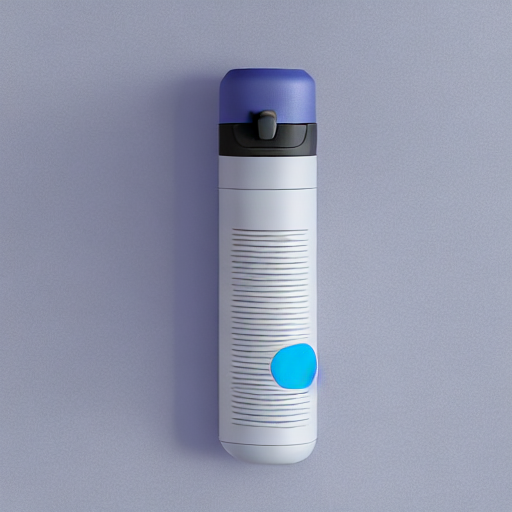

In [ ]:
display(image)

In [ ]:
image.save("product_image.png")

In [ ]:
from google.colab import files

files.download("product_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
prompts = [
    "Smart Water Bottle on gym table, fitness theme",
    "Smart Water Bottle with smartphone app interface",
    "Luxury product advertisement of Smart Water Bottle",
    "Smart Water Bottle in office environment"
]

for i, p in enumerate(prompts):
    img = pipe(
        p,
        height=512,
        width=512,
        num_inference_steps=20
    ).images[0]

    img.save(f"image_{i}.png")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
!pip install -q transformers accelerate

In [ ]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct"
)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

In [ ]:
product_description = """
Smart Water Bottle
Tracks hydration
Temperature monitoring
Mobile app integration
"""

prompt = f"""
Write a 60-second product explainer video script.

Product:
{product_description}
"""

result = generator(
    prompt,
    max_new_tokens=200
)

script = result[0]["generated_text"]

print(script)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Write a 60-second product explainer video script.

Product:

Smart Water Bottle
Tracks hydration
Temperature monitoring
Mobile app integration

Script:

[00:00] (Upbeat music playing)

[00:05] (On-screen text: "Discover the Smart Water Bottle")

[00:10] (Close-up shot of a sleek, modern water bottle)

[00:15] Narrator: "Introducing the Smart Water Bottle - the perfect companion for your hydration needs!"

[00:20] (On-screen text: "Water Intake Tracker")

[00:25] Narrator: "With built-in sensors, this smart bottle tracks your daily water intake and provides personalized hydration goals."

[00:30] (Cut to animation showing a virtual hydration goal bar filling up)

[00:35]


In [ ]:
!pip install moviepy

In [ ]:
from moviepy.video.io.VideoFileClip import VideoFileClip

avatar = VideoFileClip("avatar_video.mp4")

avatar.write_videofile(
    "final_product_explainer.mp4",
    codec="libx264"
)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)


Moviepy - Building video final_product_explainer.mp4.
MoviePy - Writing audio in final_product_explainerTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video final_product_explainer.mp4



Streaming output truncated to the last 5000 lines.
  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

t:  57%|█████▋    | 2250/3915 [05:08<01:31, 18.18it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file avatar_video.mp4, 9953280 bytes wanted but 0 bytes read,at frame 2249/3915, at time 37.48/65.24 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

t:  58%|█████▊    | 2253/3915 [05:08<01:33, 17.83it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file avatar_video.mp4, 9953280 bytes wanted but 0 bytes read,at frame 2252/3915, at time 37.53/65.24 sec. Using the last valid frame instead.